In [1]:
import numpy as np 
import h5py as h5 
import matplotlib.pyplot as plt

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.interpolate import UnivariateSpline
from scipy.optimize import minimize

from compact.lpt import *
from compact.streaming import *
from compact.model import *
from compact.plot import *

from halotools.mock_observables import tpcf_multipole


from tqdm import tqdm
import emcee

from scipy.interpolate import UnivariateSpline

import warnings
warnings.filterwarnings('ignore')

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20


# reload project when changes are made
%load_ext autoreload
%autoreload 2 

In [2]:
# load R tpcf, moments, and S tpcf 

with h5.File("/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hh_150_linbin.hdf5", "r") as hdf :
    xihh  = np.array(hdf['xi'][()])
    r      = np.array(hdf['r_cens'][()])
    sigma2 = np.diag(hdf['xi_cov'][()])

# load jk moments 
from scipy.interpolate import RectBivariateSpline

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

with h5.File(save_path + "halo_moments_jk_linbin.h5", "r") as hdf:
    #print(hdf.keys())
    #print(hdf.attrs.keys())

    keys = ['c02', 'c04', 'c12', 'c20', 'c22', 'c30', 'c40', 'm10']
    #print(keys)
    mom_dict       = {key: hdf["full"][key][:] for key in hdf["full"]}
    jk_samples = {key: hdf["jk_samples"][key][:] for key in hdf["jk_samples"]}
    cov        = hdf["cov"][:]
    rbins      = hdf.attrs["rbins"]
    L_box      = hdf.attrs["boxsize"]
    n_jk_1d    = hdf.attrs["n_jk_1d"]

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

# restructure cov matrix 
n_jk = n_jk_1d**3
jk_matrix = np.stack([jk_samples[k] for k in keys], axis=-1)  # (n_jk, n_bins, n_moments)
mean_jk = jk_matrix.mean(axis=0)
delta = jk_matrix - mean_jk
cov = (n_jk - 1) / n_jk * np.einsum('kbi,kci->ibc', delta, delta)

v12_sim = np.interp(r, rbins_c, mom_dict['m10'])

spline = RectBivariateSpline(rbins_c, rbins_c, cov[keys.index('m10')], kx=3, ky=3)

cov_v12_sim = np.diag(spline(r, r))

# rs tpcf
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr_72bin.hdf5'

with h5.File(save_path, 'r') as hdf:
    xi_ell = hdf['xi_ell'][()]
    xi_ell_cov = hdf['xi_ell_cov'][()]
    s_cens = hdf['s_cens'][()]

nells = 3
xi_ell_std = np.array(np.array_split(np.diag(xi_ell_cov)**0.5, nells))

In [3]:
gli = GetLPTInputs(pars=[0.6, 0, 0, 0, 0, 0, 0, 0, 0])

q_perp, q_par = gli.get_AP() 

In [4]:
# fit lpt biases to R tpcf, pwv mean

gli = GetLPTInputs(pars=[0.6, 0, 0, 0, 0, 0, 0, 0, 0])

rmins = np.array([10, 20]) 

x0 = np.concatenate((gli.pars, [1e-3, 1e-3]))

pars_best = np.zeros((len(rmins), 11))  # 9 parameters + softening scale

for idx, rmin in enumerate(rmins):
    mask = ((rmin < r) & (r < 130))
    
    def joint_loss(b):
        pars = b[:-2] 
        
        xihh_model = gli.xi_real(r, pars)
        v12_model  = gli.pwv_mean(r, pars) 
        
        sigma2_soft_xi = sigma2[mask] + b[-2]**2*xihh[mask]**2
        chi2_xi = sum((xihh_model[mask] - xihh[mask])**2/ sigma2_soft_xi )#
        
        sigma2_soft_v = cov_v12_sim[mask] + b[-1]**2*v12_sim[mask]**2
        chi2_v12 = sum((v12_model[mask] - v12_sim[mask])**2/ sigma2_soft_v )# 
        
        return chi2_xi + chi2_v12

    # Set alpha_s0 and alpha_s2 to fixed 0 bounds since they only affect dispersion
    bounds = [
        (0.0, 5.0),      # b_1
        (-5.0**2, 5.0**2),     # b_2
        (0.0, 0.0), #(-5.0, 5.0),     # b_s allow to vary for \sigma_12 check above
        (0.0, 0.0), #(-5.0, 5.0),     # b_3 (0.0, 0.0), #
        (0.0, 0.0), #(-50.0, 50.0),   # alpha
        (0.0, 0.0), #(-50.0, 50.0),   # alpha_v 
        (0.0, 0.0),      # alpha_s0 (Fixed)
        (0.0, 0.0),      # alpha_s2 (Fixed)
        (0.0, 0.0),     # s2FoG
        (0.0, 1.0),      # eps_soft_xi
        (0.0, 1.0),      # eps_soft_v (new par!)
    ]

    pars_best[idx] = minimize(joint_loss, 
                                x0=x0, 
                                bounds=bounds, 
                                method='nelder-mead',# 'L-BFGS-B', # 
                                options=  {'fatol': 1e-16, 'xatol': 1e-16}, #{'ftol': 1e-16, 'gtol': 1e-16}, #
                                ).x

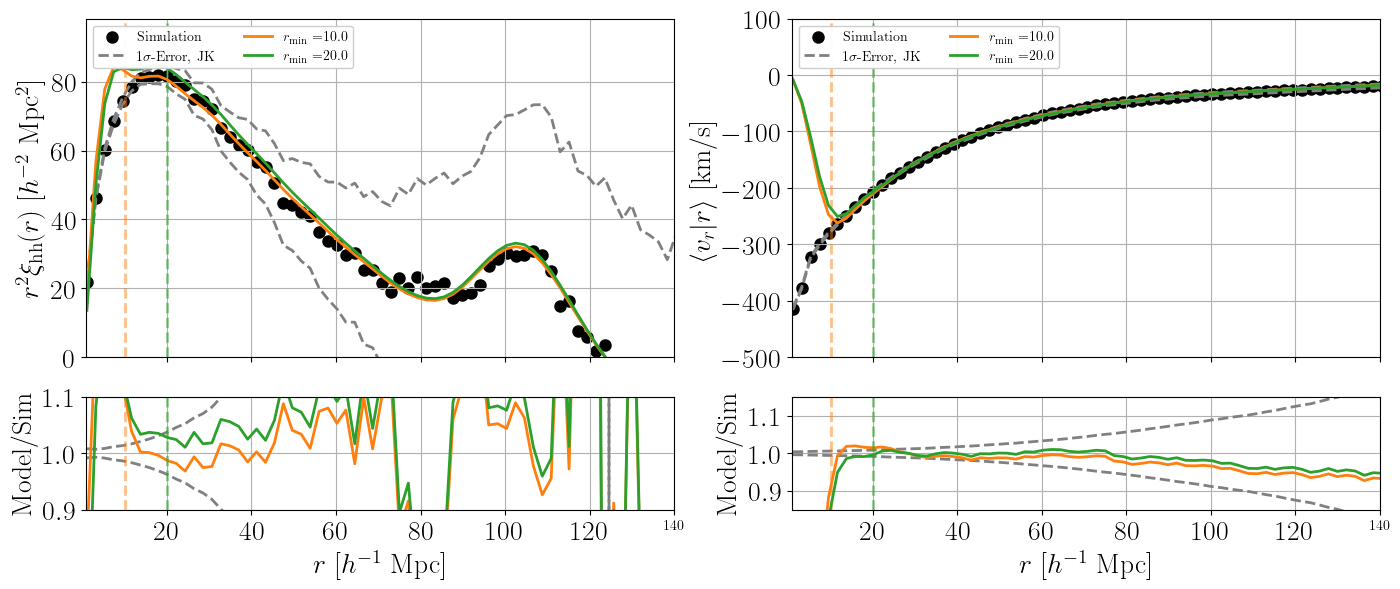

In [6]:
# inspect
fig, axes = plot_lpt_fits(r, xihh, v12_sim, sigma2, cov_v12_sim**0.5, rmins, pars_best, gli)

for ax in axes:
    ax[0].set_xscale('linear')
    ax[1].set_xscale('linear')

In [7]:
pars_best

array([[0.64497099, 0.44689159, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        1.        ],
       [0.66919622, 0.09596966, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        ]])

In [8]:
1/0.644

1.5527950310559007

In [10]:
gli.f/1.644

0.38218624480632435

In [ ]:
# test \sigma_0 prediction

cosmo=cosmology.setCosmology('planck13')  # MDPL2 uses Planck 2013

a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

from scipy.integrate import simpson

# k, Pk from your existing CAMB wrapper — same P_lin(k) table you already
# use for the LPT calls, in h/Mpc and (Mpc/h)^3 units
sigma0_sq = (gli.f * gli.conv)**2 / (6 * np.pi**2) * simpson(gli.Plin, gli.klin)
sigma0 = np.sqrt(sigma0_sq)
print(sigma0)
print(sigma0/355)

# non-linear Pk instead 
import camb
from camb import model

# MDPL2 Planck 2013 cosmology: h=0.6777, ns=0.96, sigma8=0.8228
# ombh2, omch2 fill in from your existing wrapper's Ωb, Ωm values
pars = camb.set_params(H0=67.77, ombh2=0.022183093107, omch2=0.11886096265199997, ns=0.9611)
pars.set_matter_power(redshifts=[0.1940], kmax=10.0)  # z ≈ 0.194, MDPL2 snapshot
pars.NonLinear = model.NonLinear_both

results = camb.get_results(pars)
kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=5.0, npoints=500
)
pk_nl = pk_nl[0] 

sigma0_nl_sq = (gli.f * gli.conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
sigma0_nl = np.sqrt(sigma0_nl_sq)
print(sigma0_nl)
print(sigma0_nl/355)

314.34926428252385
0.8854908853028841
344.14719993341055
0.9694287322067903


In [ ]:
gli.gsm.compute_cumulants(*pars_best[1][:-2])

gle.f**2gli.gsm.s0eft[-1]

np.float64(109.09814953671307)

In [20]:
233/h

343.8099454035709

In [7]:
1/np.sqrt(3)

np.float64(0.5773502691896258)

In [106]:
del_pars

array([47.76692348,  0.29581893])

In [47]:
# fit multipoles (mono and quad for now)
comp_bf_pars = np.concatenate((sig_pars, del_pars)) #np.array([  0.5310972 ,  np.log(55.33533501), 190.03086941,   np.log(8.22406535)]) # from compact joint fit

lpt_p0 = np.array(pars_best[1][:2])  # b_1, b_2 starting point

p0 = np.concatenate([lpt_p0, comp_bf_pars])

lpt_bounds = np.array([
            (0.0, 5.0),      # b_1
            (-5.0, 5.0),     # b_2
        ]).T

compact_bounds = np.array([
            (0, np.inf) for par in comp_bf_pars
        ]).T

# compact_bounds[:, 1] = np.array([np.log(1e-5), np.log(3*np.exp(comp_bf_pars[1]))])
# compact_bounds[:, 3] = np.array([np.log(1e-5), np.log(3*np.exp(comp_bf_pars[3]))])

Bounds = np.concatenate([lpt_bounds, compact_bounds], axis=1)

# define mu bins

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/s_mu_xi_hh.hdf5'

hdf = h5.File(save_path)

mu_bins = hdf['mu_edges'][()]
mu_bins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])

def model_multipoles(params):
    lpt_pars = params[:2]
    #A_rho, ln_sigma_rho, A_Delta, ln_sigma_Delta = params[2:]
    #compact_pars = np.array([A_rho, np.exp(ln_sigma_rho), A_Delta, np.exp(ln_sigma_Delta)])
    compact_pars = params[2:]
    lpt_params = np.concatenate([lpt_pars, np.zeros(7)])

    xir = gli.xi_real(rbins_c, lpt_params)
    xi_spline = UnivariateSpline(rbins_c, xir, s=0)

    v12 = gli.pwv_mean(rbins_c, lpt_params)
    mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

    def compact_pdf(v, rp, rl):
        uc = 1/gli.conv
        return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=compact_pars)

    s_mu = simps_integrate(
        s_c=rbins_c, mu_c=mu_bins_c,
        twopcf_function=xi_spline,
        los_pdf_function=compact_pdf,
        limit=160,
        epsilon=0.01,
        n=50,
    )
    mono = tpcf_multipole(s_mu, mu_bins, order=0)
    quad = tpcf_multipole(s_mu, mu_bins, order=2)

    return mono, quad

In [48]:

def log_prior_mono_quad(params_mcmc):
    model_params = params_mcmc[:-2]
    log_f_mono, log_f_quad = params_mcmc[-2:]

    if not np.all((model_params >= Bounds[0]) & (model_params <= Bounds[1])):
        return -np.inf
    if not (-10.0 < log_f_mono < 5.0 and -10.0 < log_f_quad < 5.0):
        return -np.inf
    return 0.0


def log_probability_mono_quad(params_mcmc, mono_sim, quad_sim, w_mono, w_quad, mask):
    lp = log_prior_mono_quad(params_mcmc)
    if not np.isfinite(lp):
        return -np.inf

    model_params = params_mcmc[:-2]
    log_f_mono, log_f_quad = params_mcmc[-2:]

    try:
        mono, quad = model_multipoles(model_params)
    except Exception:
        return -np.inf

    if not (np.all(np.isfinite(mono)) and np.all(np.isfinite(quad))):
        return -np.inf

    res_mono = (mono - mono_sim)[mask]
    res_quad = (quad - quad_sim)[mask]

    sigma2_mono = w_mono[mask]**2 * (1 + np.exp(2 * log_f_mono))
    sigma2_quad = w_quad[mask]**2 * (1 + np.exp(2 * log_f_quad))

    chi2 = np.sum(res_mono**2 / sigma2_mono) + np.sum(res_quad**2 / sigma2_quad)
    log_norm = np.sum(np.log(sigma2_mono)) + np.sum(np.log(sigma2_quad))

    return lp - 0.5 * (chi2 + log_norm)

def log_like_mono_quad(params_mcmc, mono_sim, quad_sim, w_mono, w_quad, mask):

    model_params = params_mcmc[:-2]
    log_f_mono, log_f_quad = params_mcmc[-2:]

    try:
        mono, quad = model_multipoles(model_params)
    except Exception:
        return -np.inf

    if not (np.all(np.isfinite(mono)) and np.all(np.isfinite(quad))):
        return -np.inf

    res_mono = (mono - mono_sim)[mask]
    res_quad = (quad - quad_sim)[mask]

    sigma2_mono = w_mono[mask]**2 * (1 + np.exp(2 * log_f_mono))
    sigma2_quad = w_quad[mask]**2 * (1 + np.exp(2 * log_f_quad))

    chi2 = np.sum(res_mono**2 / sigma2_mono) + np.sum(res_quad**2 / sigma2_quad)
    log_norm = np.sum(np.log(sigma2_mono)) + np.sum(np.log(sigma2_quad))

    return - 0.5 * (chi2 + log_norm)

In [49]:
monopole, quadrupole, hexadecapole = xi_ell
w_mono, w_quad, w_hexa = xi_ell_std

init_pars = np.concatenate((p0, [0, 0]))

In [50]:
log_probability_mono_quad(init_pars, monopole, quadrupole, w_mono, w_quad, rbins_c>20)

np.float64(612.8807621530715)

In [51]:
init_pars

array([ 0.66919622,  0.09596965,  0.20281935, 27.38288027, 47.76692348,
        0.29581893,  0.        ,  0.        ])

In [52]:
# run chain
from multiprocessing import Pool


ndim = len(init_pars)
nwalkers = 4 * ndim
pos = init_pars + 1e-4 * np.random.randn(nwalkers, ndim)

with Pool(processes=84) as pool:  
    mono_quad_sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability_mono_quad,
        args=(monopole, quadrupole, w_mono, w_quad, rbins_c > 20),
        pool=pool
    )
    mono_quad_sampler.run_mcmc(pos, 2_000, progress=True)

100%|██████████| 2000/2000 [48:59<00:00,  1.47s/it]


In [53]:
print(mono_quad_sampler.acceptance_fraction)

mono_quad_log_prob_samples = mono_quad_sampler.get_log_prob(discard=200, flat=True)   # shape (nsteps*nwalkers,)
mono_quad_chain_samples = mono_quad_sampler.get_chain(discard=200, flat=True)          # shape (nsteps*nwalkers, ndim)

map_idx = np.argmax(mono_quad_log_prob_samples)
mono_quad_map_params = mono_quad_chain_samples[map_idx]

mono_quad_mean_params = np.mean(mono_quad_chain_samples, axis=0)

[0.3095 0.336  0.2915 0.3025 0.255  0.339  0.376  0.3365 0.336  0.299
 0.3535 0.29   0.333  0.315  0.318  0.3555 0.3405 0.3145 0.2575 0.3155
 0.359  0.31   0.327  0.3375 0.3105 0.3145 0.352  0.342  0.33   0.309
 0.344  0.3085]


In [54]:
print(mono_quad_sampler.get_autocorr_time())

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [100.21152584 108.13429189  93.25091597 150.26865491 140.29830213
 204.81245317 141.57778025 146.39169699]

In [103]:
init_pars.shape

(8,)

In [104]:
mono_quad_map_params.shape

(8,)

In [105]:
mono_quad_map_params

array([ 0.6479204 ,  0.05072458,  0.23539148,  9.78702925, 35.69568197,
        7.26847406, -3.01698972, -2.68753305])

In [ ]:
mono_quad_map_params

array([ 0.61501681,  0.33345064,  0.3034241 , 13.80610866, 24.11581175,
        0.31029725, -2.77558981,  0.22055302])

In [129]:
np.exp(0.22)

np.float64(1.2460767305873808)

In [69]:
chain.shape

(2000, 32, 8)

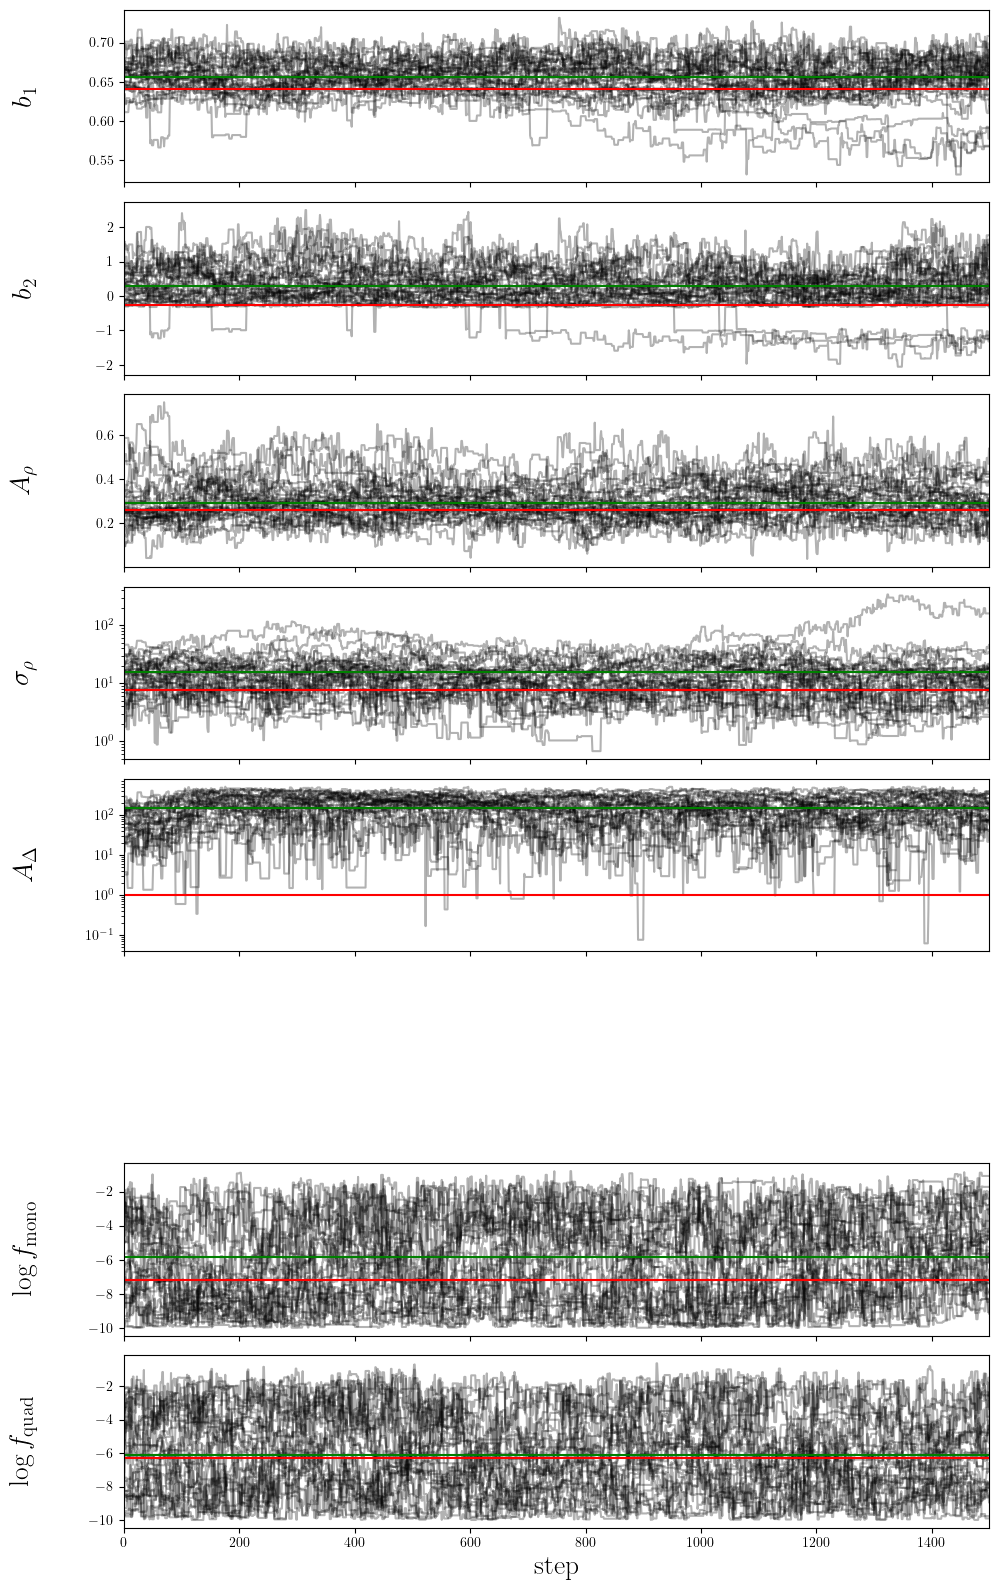

In [71]:

labels = [
    r"$b_1$", r"$b_2$",
    r"$A_\rho$", r"$\sigma_\rho$", r"$A_\Delta$", r"$\sigma_\Delta$",
    r"$\log f_{\rm mono}$", r"$\log f_{\rm quad}$", r"$\log f_{\rm hexa}$",
]

chain = mono_quad_sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)
ndim = chain.shape[2]

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2*ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]

    if i == 5:
        #ax.remove
        #continue
        fig.delaxes(ax)
    
    ax.plot(chain[500:, :, i], alpha=0.3, color='k')
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(mono_quad_map_params[i], c='r')
    ax.axhline(mono_quad_mean_params[i], c='g')
    ax.margins(x=0)

    # if i < 6:
    #     ax.axhline(Bounds[0][i], c='b', alpha=0.5, ls=':')
    #     ax.axhline(Bounds[1][i], c='b', alpha=0.5, ls=':')

    if i > 2 and i < 6:
       ax.set_yscale('log')



axes[-1].set_xlabel("step")
plt.tight_layout()
plt.show()

In [34]:
print(np.exp(mono_quad_mean_params[-2])*100)
print(np.exp(mono_quad_mean_params[-1])*100)

0.4319753682411681
0.48653421175212347


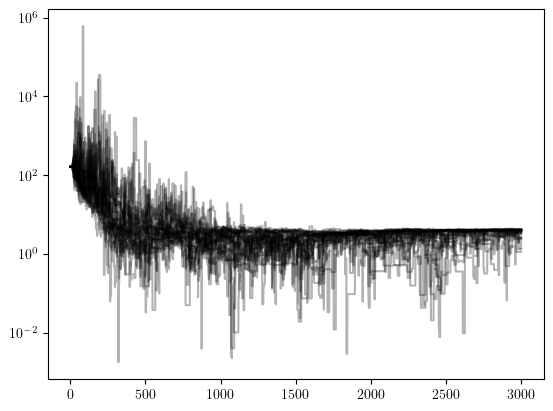

In [21]:
plt.plot(chain[:, :, 4]/chain[:, :, 5], alpha=0.3, color='k')
plt.yscale('log')
plt.show()

(2112, 8)


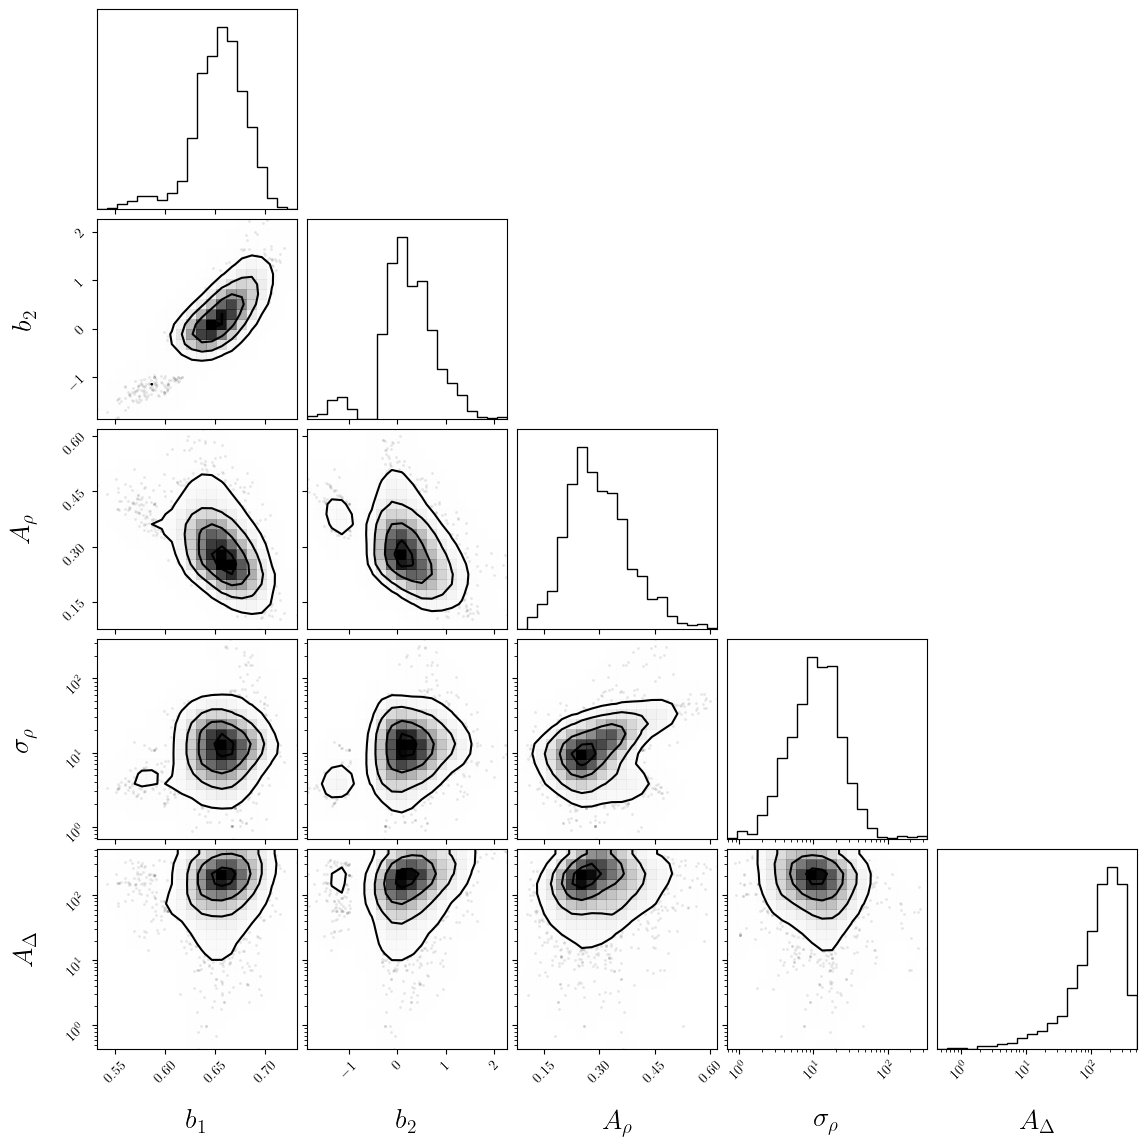

In [72]:
flat_samples = mono_quad_sampler.get_chain(discard=1_000, thin=15, flat=True)
print(flat_samples.shape)

flat_samples_fnl = np.delete(flat_samples, 5, axis=1)

import corner

fig = corner.corner(
    flat_samples_fnl[:, :-2], labels=labels[:-2], axes_scale=['linear', 'linear', 'linear', 'log', 'log'], smooth=1
);

In [118]:
mono_quad_mean_params.shape
mono_quad_mean_params_fixed = np.copy(mono_quad_mean_params)
mono_quad_mean_params_fixed[3] = np.exp(mono_quad_mean_params[3])
mono_quad_mean_params_fixed[5] = np.exp(mono_quad_mean_params[5])

In [60]:
# mono and quad bf
lpt_params = np.concatenate([mono_quad_mean_params[:2], np.zeros(7)])

xir = gli.xi_real(rbins_c, lpt_params)
xi_spline = UnivariateSpline(rbins_c, xir, s=0)

v12 = gli.pwv_mean(rbins_c, lpt_params)
mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

def compact_pdf(v, rp, rl):
    uc = 1/gli.conv # unit conversion
    r = np.sqrt(rp**2 + rl**2)
    return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=mono_quad_mean_params[2:-2])

compact_mono_quad_BF_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=xi_spline,
    los_pdf_function=compact_pdf,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_mono_quad_BF_monopole = tpcf_multipole(
    compact_mono_quad_BF_s_mu,
    mu_bins, 
    order=0
)
compact_mono_quad_BF_quadrupole = tpcf_multipole(
    compact_mono_quad_BF_s_mu, 
    mu_bins, 
    order=2
)
compact_mono_quad_BF_hexadecapole = tpcf_multipole(
    compact_mono_quad_BF_s_mu, 
    mu_bins, 
    order=4)

Text(0.5, 0.98, 'MDPL2 halos: streaming model with LPT ($\\xi^R, \\langle v_r|r\\rangle$) + compact ($P(v_{\\rm los}|r_\\perp, r_{\\rm los})$) inputs')

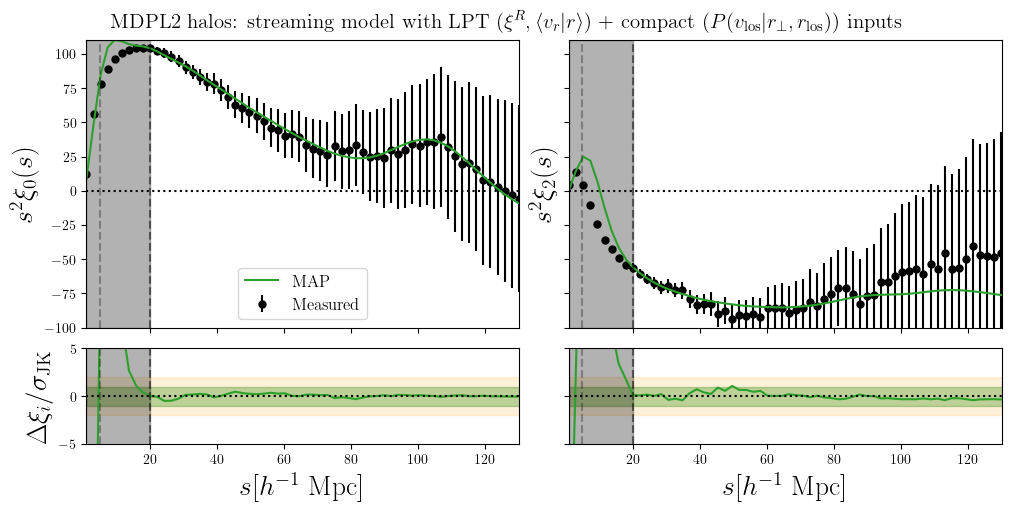

In [61]:
fig, axes = plot_multipoles_n_residuals(rbins_c, xi_ell, errs=xi_ell_std, preds=[compact_mono_quad_BF_monopole, compact_mono_quad_BF_quadrupole, compact_mono_quad_BF_hexadecapole], label='MAP', plot_hex=False)

compact_mono_quad_BF_multipoles = [compact_mono_quad_BF_monopole, compact_mono_quad_BF_quadrupole]

rcut = 20

multipoles = xi_ell
for i, lm in enumerate(compact_mono_quad_BF_multipoles):

    axes[0, i].axvline(rcut, c='k', alpha=0.5, ls='--')
    axes[1, i].axvline(rcut, c='k', alpha=0.5, ls='--')

    axes[0, i].axvline(5, c='k', alpha=0.3, ls='--')
    axes[1, i].axvline(5, c='k', alpha=0.3, ls='--')

    axes[0, i].fill_betweenx(np.array([-100, 110]), 1, rcut, color='k', alpha=0.3)
    axes[1, i].fill_betweenx(np.array([-100, 110]), 1, rcut, color='k', alpha=0.3)

    #axes[0, i].fill_between(rbins_c, rbins_c**2*(multipoles[i] + xi_ell_std[i]), rbins_c**2*(multipoles[i] - xi_ell_std[i]), color='k', alpha=0.2, ls='--')

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 130))
axes[0, 1].set_xlim((1, 130))

axes[1, 0].set_ylim((-5, 5))
axes[1, 1].set_ylim((-5, 5))


axes[0, 0].legend(loc='lower center', fontsize=12)

fig.suptitle(r'MDPL2 halos: streaming model with LPT ($\xi^R, \langle v_r|r\rangle$) + compact ($P(v_{\rm los}|r_\perp, r_{\rm los})$) inputs', fontsize=15)